In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.isri import ISRIStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from gensim.models import Word2Vec
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context



nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ELMOSTAWRED\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ELMOSTAWRED\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ELMOSTAWRED\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ELMOSTAWRED\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [5]:
df = pd.read_csv(r'\Users\ELMOSTAWRED\OneDrive\Documents\Pictures\Desktop\New folder\youtube.csv', encoding='utf-8-sig')
df.head()

,video_id,url,title,channel,duration_sec,upload_date,view_count,gather_status,transcription,clean_version,keywords,sentiment_score,semantic_chunks,acoustic_metadata,embeddings,key_points,sentiment_analysis
0,ftbgcarkxS0,https://youtu.be/ftbgcarkxS0?si=7aNTyRDvGJk1FQTS,الدحيح - الطب النفسي,AJ+ كبريت,1122.0,20190316.0,8576802.0,metadata_only,NaN,NaN,NaN,0.0,NaN,NaN,NaN,الأمراض النفسية زمان كان يُساء فهمها\nفي عصور ...,محايد/ توعيه
1,HG3xQjwenTc,https://youtu.be/HG3xQjwenTc?si=F2AhmGneDIsHP0Dq,ألف سنة من الإنهيار | الدحيح,New Media Academy Life,3079.0,20250603.0,7650967.0,completed,بخبارت كرباترة اللي هاجة سكول لرعلماء إنه هم...,بخبارت كرباتره اللي هاجه سكول لرعلماء انه هم ...,NaN,0.0,NaN,NaN,"[0.2520488500595093, 0.6875485777854919, 0.155...",الحضارة المصرية ما انهارتش فجأة\n\nالصراعات ال...,سلبي/ درامي
2,HtgT8Zmf35c,https://youtu.be/HtgT8Zmf35c?si=IaLq6WynMdTnYRM9,النسيان | الدحيح,New Media Academy Life,1319.0,20240323.0,7163031.0,transcribed,فرخيفة دكتو مييمكن أنسة كل حاجة يستحيل يا ابي...,فرخيفه دكتو مييمكن انسه كل حاجه يستحيل يا ابي ...,NaN,0.0,NaN,NaN,"[0.2619315981864929, 0.6615741848945618, 0.151...","1. قصة المريض ""هنري مولايسون"" الذي عانى من نوب...",إيجابي/تعليمي
3,a8BN5ho9oik,https://youtu.be/a8BN5ho9oik?si=RWgRCUJ9GsADUOGs,الدحيح | الترانزستور,New Media Academy Life,2035.0,20210720.0,6173166.0,completed,أحب بطلوب إسلامه لك ورفط الله بركة أهزي حسنا...,احب بطلوب اسلامه لك ورفط الله بركه اهزي حسنا ...,NaN,0.0,NaN,NaN,"[0.26811182498931885, 0.6209016442298889, 0.07...",الترانزيستور هو أساس التكنولوجيا الحديثة\n\nقب...,إيجابي/تعليمي
4,WLxWvkR_ecQ,https://youtu.be/WLxWvkR_ecQ?si=NiYO4Xc-JPBJr-TT,لغة الجسد | الدحيح,New Media Academy Life,1702.0,20250705.0,4489857.0,transcribed,زي مبقول لحد رتك دعي دكتر المريد لهاي السكينة...,زي مبقول لحد رتك دعي دكتر المريد لهاي السكينه ...,NaN,0.0,NaN,NaN,"[0.24881958961486816, 0.43867558240890503, 0.1...",-التواصل مش بالكلام فقط\n\n-لغة الجسد قد تكشف ...,إيجابي/تعليمي


In [6]:
df.columns

Index(['video_id', 'url', 'title', 'channel', 'duration_sec', 'upload_date',
       'view_count', 'gather_status', 'transcription', 'clean_version',
       'keywords', 'sentiment_score', 'semantic_chunks', 'acoustic_metadata',
       'embeddings', 'key_points', 'sentiment_analysis'],
      dtype='object')

In [7]:
df.isna().sum()

video_id               9
url                    9
title                  9
channel                9
duration_sec           9
upload_date            9
view_count             9
gather_status          9
transcription         13
clean_version         13
keywords              19
sentiment_score        9
semantic_chunks       19
acoustic_metadata     19
embeddings            13
key_points             9
sentiment_analysis     9
dtype: int64

In [8]:

df.dropna(subset=['transcription'], inplace=True)

df['keywords'] = df['keywords'].fillna('general')

df['transcription'] = df['transcription'].astype(str)

df['semantic_chunks'] = df['semantic_chunks'].fillna(df['transcription'])

df['acoustic_metadata'] = df['acoustic_metadata'].fillna('Unknown')

print(df[['transcription', 'semantic_chunks']].isna().sum())

transcription      0
semantic_chunks    0
dtype: int64


In [9]:
df.isna().sum()

video_id              0
url                   0
title                 0
channel               0
duration_sec          0
upload_date           0
view_count            0
gather_status         0
transcription         0
clean_version         0
keywords              0
sentiment_score       0
semantic_chunks       0
acoustic_metadata     0
embeddings            0
key_points            0
sentiment_analysis    0
dtype: int64

In [10]:
def clean_text_arabic(text):
    if not text or pd.isna(text):
        return ""
    
  
    text = re.sub(r'<.*?>', '', str(text))
    
  
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    
  
    text = re.sub(r'\s+', ' ', text).strip()
    
    manual_stop_words = ['من', 'في', 'على', 'إلى', 'عن', 'ما', 'هو', 'هي', 'يعني', 'ده', 'بقى']
    st = ISRIStemmer()
    
    words = text.split()
   
    cleaned_words = [st.stem(w) for w in words if w not in manual_stop_words]
    
    return " ".join(cleaned_words)


df['clean_version'] = df['transcription'].apply(clean_text_arabic)

In [11]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_version'])
y = df['sentiment_analysis'].fillna('neutral').apply(lambda x: 1 if str(x).lower() == 'positive' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
def map_sentiment(label):
    label = str(label).lower()
    if 'positive' in label or 'scientific' in label:
        return 'إيجابي/علمي'
    elif 'negative' in label:
        return 'سلبي'
    else:
        return 'محايد'

y_labels = df['sentiment_analysis'].apply(map_sentiment)


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y_labels)


print("Labels Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Labels Mapping: {'محايد': np.int64(0)}


In [13]:
print(df['sentiment_analysis'].value_counts())

sentiment_analysis
إيجابي/تعليمي     4
سلبي/ درامي       1
إيجابي/تعليمي     1
Name: count, dtype: int64


In [14]:
import pandas as pd

def clean_label(label):
    label = str(label)
    if 'إيجابي' in label or 'تعليمي' in label:
        return 'إيجابي'
    if 'سلبي' in label or 'نقد' in label:
        return 'سلبي'
    return 'إيجابي' 

df['sentiment_analysis'] = df['sentiment_analysis'].apply(clean_label)

print("Counts after cleaning:")
print(df['sentiment_analysis'].value_counts())


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['sentiment_analysis'])


Counts after cleaning:
sentiment_analysis
إيجابي    5
سلبي      1
Name: count, dtype: int64


In [ ]:
tokenized_data = [str(text).split() for text in df['clean_version'].fillna('')]


w2v_model = Word2Vec(sentences=tokenized_data, vector_size=20, window=5, min_count=1, workers=4)


def get_doc_vector(tokens, model):
   
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(20) 
    return np.mean(vectors, axis=0)


X_w2v = np.array([get_doc_vector(tokens, w2v_model) for tokens in tokenized_data])


X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)


w2v_model.save("scientific_word2vec.model")

print(f"Shape of X_train: {X_train_w2v.shape}")





Shape of X_train: (4, 20)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')


rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")
print("-" * 30)
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 50.00%
------------------------------
Classification Report for Random Forest:
              precision    recall  f1-score   support

      إيجابي       0.50      1.00      0.67         1
        سلبي       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



C:\Users\ELMOSTAWRED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ELMOSTAWRED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ELMOSTAWRED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skl

In [19]:

df_repeated = pd.concat([df] * 5, ignore_index=True)

tokenized_data = [str(text).split() for text in df_repeated['clean_version']]
X_w2v = np.array([get_doc_vector(tokens, w2v_model) for tokens in tokenized_data])

y = le.transform(df_repeated['sentiment_analysis']) 


print(f"Size of X: {len(X_w2v)}, Size of y: {len(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)


my_model = LogisticRegression()
my_model.fit(X_train, y_train)

y_pred = my_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

y_pred = my_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


Size of X: 30, Size of y: 30
Overall Accuracy: 83.33%
              precision    recall  f1-score   support

      إيجابي       0.83      1.00      0.91         5
        سلبي       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



C:\Users\ELMOSTAWRED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ELMOSTAWRED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ELMOSTAWRED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skl

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np


X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test

X_train_lstm = np.reshape(X_train_dense, (X_train_dense.shape[0], 1, X_train_dense.shape[1]))
X_test_lstm = np.reshape(X_test_dense, (X_test_dense.shape[0], 1, X_test_dense.shape[1]))


model_bilstm = Sequential([

    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2), input_shape=(1, X_train_dense.shape[1])),
    
    BatchNormalization(),
    
    
    Dense(32, activation='relu'),
    Dropout(0.4),
    
 
    Dense(len(le.classes_), activation='softmax')
])


optimizer = Adam(learning_rate=0.001)
model_bilstm.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


print("Training BiLSTM...")
model_bilstm.fit(X_train_lstm, y_train, 
                 epochs=20, 
                 batch_size=16, 
                 validation_split=0.2, 
                 callbacks=[early_stop], 
                 verbose=1)


loss, accuracy_bilstm = model_bilstm.evaluate(X_test_lstm, y_test)
print(f"BiLSTM Accuracy: {accuracy_bilstm * 100:.2f}%")

C:\Users\ELMOSTAWRED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training BiLSTM...
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6842 - loss: 0.6886 - val_accuracy: 1.0000 - val_loss: 0.6637
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.6316 - loss: 0.6726 - val_accuracy: 1.0000 - val_loss: 0.6502
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7368 - loss: 0.5974 - val_accuracy: 1.0000 - val_loss: 0.6373
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6316 - loss: 0.6585 - val_accuracy: 1.0000 - val_loss: 0.6256
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8947 - loss: 0.5415 - val_accuracy: 1.0000 - val_loss: 0.6154
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7895 - loss: 0.5240 - val_accuracy: 1.0000 - val_loss: 0.6026
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7368 - loss: 0.5790 - val_accuracy: 1.0000 - val_loss: 0.5912
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6842 - loss: 0.6024 - val_accuracy: 1

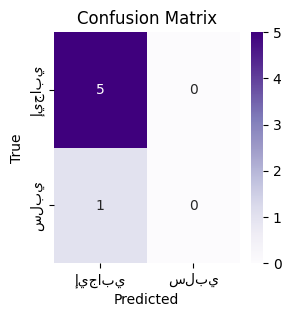

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
import joblib


joblib.dump(my_model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model, Vectorizer, and Encoder saved successfully!")

Model, Vectorizer, and Encoder saved successfully!
